In [6]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load your stage 1 model and encoders
m1 = joblib.load(r'C:\Users\Karnaveer Singh\Justice_Hq\models\stage1_binary.pkl')
encoders = joblib.load(r'C:\Users\Karnaveer Singh\Justice_Hq\models\feature_encoders.pkl')
le_y1 = joblib.load(r'C:\Users\Karnaveer Singh\Justice_Hq\models\le_stage1.pkl')

# Load modeling dataset
df = pd.read_csv(r'C:\Users\Karnaveer Singh\Justice_Hq\data\processed\df_model.csv')

FEATURE_COLS = [
    'state_code', 'dist_code', 'court_no',
    'judge_position', 'type_name',
    'filing_year', 'filing_quarter',
    'court_historical_median_resolution', 'pending_cases_count'
]

X = df[FEATURE_COLS].copy()
for col in ['state_code', 'dist_code', 'court_no', 'judge_position', 'type_name']:
    X[col] = encoders[col].transform(X[col].astype(str))

print(f"X shape: {X.shape}")
print("Loaded successfully")

X shape: (493776, 9)
Loaded successfully


In [7]:
# Use a sample for speed — SHAP is slow on 500k rows
X_sample = X.sample(5000, random_state=42)

# TreeExplainer is optimized for XGBoost
explainer = shap.TreeExplainer(m1)
shap_values = explainer.shap_values(X_sample)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Classes: {le_y1.classes_}")

SHAP values shape: (5000, 9)
Classes: ['0_under_6months' '1_over_6months']


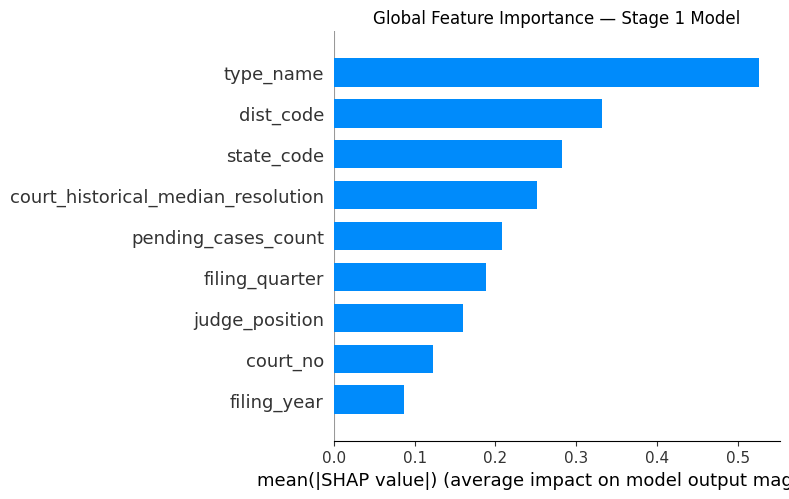

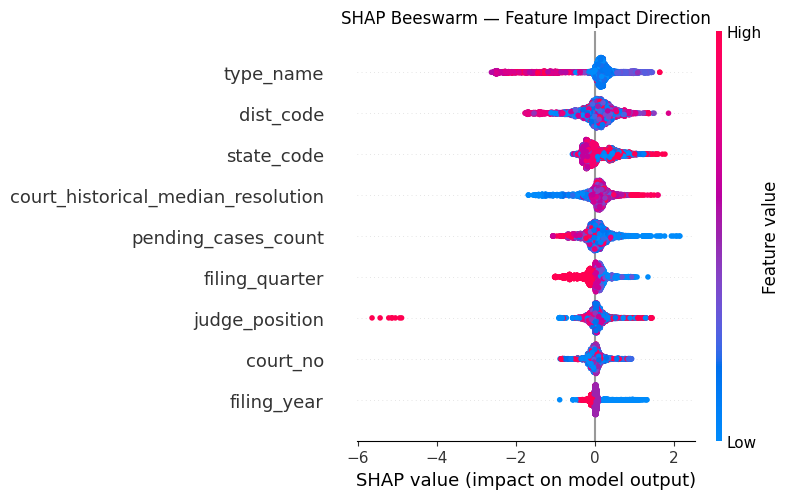

In [8]:
# Global feature importance — which features matter most overall
shap.summary_plot(shap_values, X_sample, 
                  feature_names=FEATURE_COLS,
                  plot_type='bar',
                  show=False)
plt.title('Global Feature Importance — Stage 1 Model')
plt.tight_layout()
plt.savefig(r'C:\Users\Karnaveer Singh\Justice_Hq\notebooks\shap_global.png')
plt.show()

# Beeswarm plot — shows direction of impact too
shap.summary_plot(shap_values, X_sample,
                  feature_names=FEATURE_COLS,
                  show=False)
plt.title('SHAP Beeswarm — Feature Impact Direction')
plt.tight_layout()
plt.savefig(r'C:\Users\Karnaveer Singh\Justice_Hq\notebooks\shap_beeswarm.png')
plt.show()

In [10]:
# Reverse lookup maps
state_key = pd.read_csv(r'C:\Users\Karnaveer Singh\Justice_Hq\csv\keys\cases_state_key.csv')
type_clean = pd.read_csv(r'C:\Users\Karnaveer Singh\Justice_Hq\data\lookups\type_clean.csv')

state_map = dict(zip(state_key['state_code'], state_key['state_name']))
type_map = dict(zip(type_clean['type_name'], type_clean['type_canonical']))

def explain_case_readable(case_idx, X_sample, shap_values, feature_names, le_y1, m1, encoders):
    case = X_sample.iloc[case_idx]
    sv = shap_values[case_idx]
    pred = m1.predict([case])[0]
    pred_proba = m1.predict_proba([case])[0]
    
    feature_impacts = sorted(
        zip(feature_names, sv, case.values),
        key=lambda x: abs(x[1]),
        reverse=True
    )
    
    print(f"Prediction: {le_y1.classes_[pred]}")
    print(f"Confidence: {pred_proba[pred]*100:.1f}%")
    print(f"\nTop 3 factors:")
    
    for feat, shap_val, feat_val in feature_impacts[:3]:
        direction = "↑ increases delay risk" if shap_val > 0 else "↓ reduces delay risk"
        
        # Decode feature value to readable
        if feat == 'state_code':
            raw = encoders[feat].inverse_transform([int(feat_val)])[0]
            readable = state_map.get(int(raw), raw)
        elif feat == 'type_name':
            raw = encoders[feat].inverse_transform([int(feat_val)])[0]
            readable = type_map.get(float(raw), raw)
        elif feat == 'filing_quarter':
            readable = f"Q{int(feat_val)}"
        elif feat == 'court_historical_median_resolution':
            readable = f"{feat_val:.0f} days historical median"
        elif feat == 'pending_cases_count':
            readable = f"{feat_val:.0f} pending cases"
        else:
            readable = str(int(feat_val))
            
        print(f"  {feat}: {readable} → {direction} (impact: {shap_val:+.3f})")

# Test
for i in [0, 1, 2]:
    print(f"\n{'='*50}")
    print(f"Case {i+1}:")
    explain_case_readable(i, X_sample, shap_values, FEATURE_COLS, le_y1, m1, encoders)


Case 1:
Prediction: 0_under_6months
Confidence: 92.3%

Top 3 factors:
  type_name: t. ev. suit → ↓ reduces delay risk (impact: -1.756)
  court_historical_median_resolution: 269 days historical median → ↓ reduces delay risk (impact: -0.706)
  pending_cases_count: 114395 pending cases → ↓ reduces delay risk (impact: -0.670)

Case 2:
Prediction: 1_over_6months
Confidence: 87.3%

Top 3 factors:
  filing_quarter: Q1 → ↑ increases delay risk (impact: +0.244)
  dist_code: 12 → ↑ increases delay risk (impact: +0.236)
  court_historical_median_resolution: 711 days historical median → ↑ increases delay risk (impact: +0.221)

Case 3:
Prediction: 1_over_6months
Confidence: 80.4%

Top 3 factors:
  state_code: Tamil Nadu → ↑ increases delay risk (impact: +0.385)
  type_name: rent miscellaneous → ↑ increases delay risk (impact: +0.314)
  filing_quarter: Q2 → ↑ increases delay risk (impact: +0.109)


## Day 6 Complete — SHAP Explainability Layer

Every prediction now comes with:
- Confidence percentage
- Top 3 delay drivers in plain English
- Direction of impact (increases/reduces delay risk)

Example output:
"80.4% chance of delay. Primary factors:
 1. Tamil Nadu — historically slow courts (+0.385)
 2. Rent miscellaneous case type (+0.314)  
 3. Filed in Q2 (+0.109)"

This is the explanation layer that makes JusticeIQ a product,
not just a model.

In [11]:
import joblib

joblib.dump(explainer, r'C:\Users\Karnaveer Singh\Justice_Hq\models\shap_explainer.pkl')
joblib.dump(state_map, r'C:\Users\Karnaveer Singh\Justice_Hq\models\state_map.pkl')
joblib.dump(type_map, r'C:\Users\Karnaveer Singh\Justice_Hq\models\type_map.pkl')

print("Saved. Day 6 complete.")

Saved. Day 6 complete.
